In [28]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np # linear algebra


In [29]:
df=pd.read_csv("./Heart_Attack_Risk_Levels_Dataset.csv")
df

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result,Risk_Level,Recommendation
0,63,1,66,160,83,160.0,1.80,0.012,negative,Moderate,Monitor closely and consult doctor
1,20,1,94,98,46,296.0,6.75,1.060,positive,High,Immediate medical attention
2,56,1,64,160,77,270.0,1.99,0.003,negative,Moderate,Monitor closely and consult doctor
3,66,1,70,120,55,270.0,13.87,0.122,positive,High,Immediate medical attention
4,54,1,64,112,65,300.0,1.08,0.003,negative,Moderate,Monitor closely and consult doctor
...,...,...,...,...,...,...,...,...,...,...,...
1314,44,1,94,122,67,204.0,1.63,0.006,negative,Moderate,Monitor closely and consult doctor
1315,66,1,84,125,55,149.0,1.33,0.172,positive,High,Immediate medical attention
1316,45,1,85,168,104,96.0,1.24,4.250,positive,High,Immediate medical attention
1317,54,1,58,117,68,443.0,5.80,0.359,positive,High,Immediate medical attention


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1319 entries, 0 to 1318
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1319 non-null   int64  
 1   Gender                    1319 non-null   int64  
 2   Heart rate                1319 non-null   int64  
 3   Systolic blood pressure   1319 non-null   int64  
 4   Diastolic blood pressure  1319 non-null   int64  
 5   Blood sugar               1319 non-null   float64
 6   CK-MB                     1319 non-null   float64
 7   Troponin                  1319 non-null   float64
 8   Result                    1319 non-null   object 
 9   Risk_Level                1319 non-null   object 
 10  Recommendation            1319 non-null   object 
dtypes: float64(3), int64(5), object(3)
memory usage: 113.5+ KB


In [31]:
df.isnull().sum()

Age                         0
Gender                      0
Heart rate                  0
Systolic blood pressure     0
Diastolic blood pressure    0
Blood sugar                 0
CK-MB                       0
Troponin                    0
Result                      0
Risk_Level                  0
Recommendation              0
dtype: int64

In [32]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1319.0,56.193328,13.638173,14.000,47.000,58.000,65.0000,103.0
Gender,1319.0,0.659591,0.474027,0.000,0.000,1.000,1.0000,1.0
Heart rate,1319.0,78.336619,51.630270,20.000,64.000,74.000,85.0000,1111.0
Systolic blood pressure,1319.0,127.170584,26.122720,42.000,110.000,124.000,143.0000,223.0
Diastolic blood pressure,1319.0,72.269143,14.033924,38.000,62.000,72.000,81.0000,154.0
Blood sugar,1319.0,146.634344,74.923045,35.000,98.000,116.000,169.5000,541.0
CK-MB,1319.0,15.274306,46.327083,0.321,1.655,2.850,5.8050,300.0
Troponin,1319.0,0.360942,1.154568,0.001,0.006,0.014,0.0855,10.3


In [33]:
df.columns

Index(['Age', 'Gender', 'Heart rate', 'Systolic blood pressure',
       'Diastolic blood pressure', 'Blood sugar', 'CK-MB', 'Troponin',
       'Result', 'Risk_Level', 'Recommendation'],
      dtype='object')

In [34]:
df['Gender'] = df['Gender'].map({1: 'Male', 0: 'Female'})

# Create age bins
df['Age Group'] = pd.cut(df['Age'], bins=[0, 30, 45, 60, 75, 100], 
                        labels=['<30', '30-45', '45-60', '60-75', '75+'])

# Create blood pressure categories
df['BP Category'] = pd.cut(df['Systolic blood pressure'], 
                          bins=[0, 90, 120, 140, 160, 180, 200, 220, 300],
                          labels=['Low', 'Normal', 'Elevated', 'Stage 1 Hypertension', 
                                 'Stage 2 Hypertension', 'Hypertensive Crisis', 
                                 'Severe Hypertension', 'Critical'])

# Create blood sugar categories
df['Blood Sugar Category'] = pd.cut(df['Blood sugar'],
                                  bins=[0, 70, 100, 125, 200, 300, 400, 500, 600],
                                  labels=['Low', 'Normal', 'Prediabetes', 'Diabetes',
                                          'High Diabetes', 'Very High', 'Extreme', 'Dangerous'])

# Create heart rate categories
df['Heart Rate Category'] = pd.cut(df['Heart rate'],
                                 bins=[0, 40, 60, 100, 140, 200, 300, 500, 1200],
                                 labels=['Very Low', 'Low', 'Normal', 'Elevated',
                                         'High', 'Very High', 'Extreme', 'Dangerous'])

In [35]:
risk_dist = px.pie(df, names='Risk_Level', title='Distribution of Risk Levels',
                color_discrete_sequence=px.colors.sequential.RdBu)

In [36]:
# Age Distribution by Risk Level
age_dist = px.histogram(df, x='Age', color='Risk_Level', nbins=30,
                       title='Age Distribution by Risk Level',
                       barmode='overlay', opacity=0.7,
                       color_discrete_sequence=px.colors.sequential.RdBu)
age_dist.update_layout(bargap=0.1)
age_dist.show()

In [37]:
gender_dist = px.histogram(df, x='Gender', color='Risk_Level',
                          title='Gender Distribution by Risk Level',
                          barmode='group',
                          color_discrete_sequence=px.colors.sequential.RdBu)
gender_dist.show()

In [38]:
# Troponin vs CK-MB by Risk Level
biomarkers = px.scatter(df, x='CK-MB', y='Troponin', color='Risk_Level',
                       title='Troponin vs CK-MB by Risk Level',
                       log_x=True, log_y=True,
                       color_discrete_sequence=px.colors.sequential.RdBu)
biomarkers.show()

In [39]:
# Blood Pressure Distribution
bp_dist = px.box(df, x='Risk_Level', y='Systolic blood pressure',
                title='Systolic Blood Pressure by Risk Level',
                color='Risk_Level',
                color_discrete_sequence=px.colors.sequential.RdBu)
bp_dist.show()

In [40]:
# Select numerical columns for correlation
num_cols = ['Age', 'Heart rate', 'Systolic blood pressure', 
            'Diastolic blood pressure', 'Blood sugar', 'CK-MB', 'Troponin']

# Create correlation matrix
corr_matrix = df[num_cols].corr()

# Plot heatmap
corr_heatmap = px.imshow(corr_matrix, text_auto=True,
                        title='Correlation Heatmap of Numerical Variables',
                        color_continuous_scale='RdBu')
corr_heatmap.update_layout(height=600)
corr_heatmap.show()

In [41]:


# Age vs Biomarkers by Risk Level
fig = make_subplots(rows=1, cols=2, subplot_titles=('Age vs CK-MB', 'Age vs Troponin'))

fig.add_trace(
    go.Scatter(
        x=df['Age'],
        y=df['CK-MB'],
        mode='markers',
        marker=dict(
            color=df['Troponin'],
            colorscale='RdBu',
            showscale=True,
            size=8,
            opacity=0.7
        )
    ),
    row=1,
    col=1
)

fig.add_trace(
    go.Scatter(
        x=df['Age'],
        y=df['Troponin'],
        mode='markers',
        marker=dict(
            color=df['CK-MB'],
            colorscale='RdBu',
            showscale=True,
            size=8,
            opacity=0.7
        )
    ),
    row=1,
    col=2
)

fig.update_layout(
    title_text='Age vs Biomarkers (Color represents the other biomarker)',
    height=500
)
fig.show()


In [42]:
# BP Categories by Risk Level
bp_cat = px.histogram(df, x='BP Category', color='Risk_Level',
                     title='Blood Pressure Categories by Risk Level',
                     barmode='group',
                     color_discrete_sequence=px.colors.sequential.RdBu)
bp_cat.show()

In [43]:
# Blood Sugar Categories by Risk Level
bs_cat = px.histogram(df, x='Blood Sugar Category', color='Risk_Level',
                     title='Blood Sugar Categories by Risk Level',
                     barmode='group',
                     color_discrete_sequence=px.colors.sequential.RdBu)
bs_cat.show()

In [44]:
# 3D Scatter Plot
scatter_3d = px.scatter_3d(df, x='Age', y='Systolic blood pressure', z='Troponin',
                          color='Risk_Level', size='CK-MB',
                          title='3D View: Age, Blood Pressure, and Troponin by Risk Level',
                          color_discrete_sequence=px.colors.sequential.RdBu,
                          opacity=0.7)
scatter_3d.update_layout(height=700)
scatter_3d.show()

In [45]:
import plotly.graph_objects as go

df['Risk_Level_Num'] = df['Risk_Level'].astype('category').cat.codes

fig = go.Figure(data=
    go.Parcoords(
        line=dict(
            color=df['Risk_Level_Num'],
            colorscale='RdBu',
            showscale=True,
            cmin=df['Risk_Level_Num'].min(),
            cmax=df['Risk_Level_Num'].max()
        ),
        dimensions=list([
            dict(label='Age', values=df['Age']),
            dict(label='Systolic BP', values=df['Systolic blood pressure']),
            dict(label='Diastolic BP', values=df['Diastolic blood pressure']),
            dict(label='Blood Sugar', values=df['Blood sugar']),
            dict(label='CK-MB', values=df['CK-MB']),
            dict(label='Troponin', values=df['Troponin'])
        ])
    )
)

fig.update_layout(title='Parallel Coordinates Plot of Risk Factors')
fig.show()

In [46]:
fig1 = px.pie(df, names='Result', title='Distribution of Heart Attack Results (Positive vs Negative)',
              color_discrete_sequence=px.colors.sequential.RdBu)
fig1.show()

In [47]:
categorical_cols = ['Gender', 'Risk_Level']

for col in categorical_cols:
    fig = px.pie(df, names=col, title=f'Distribution of {col}',
                 color_discrete_sequence=px.colors.sequential.RdBu)
    fig.show()

In [48]:
df['Age_Group'] = pd.cut(df['Age'], bins=[0, 35, 50, 65, 100], labels=['Young', 'Mid-age', 'Senior', 'Elder'])

df['Sugar_Level'] = pd.cut(df['Blood sugar'], bins=[-1, 80, 120, 200, df['Blood sugar'].max()],
                           labels=['Low', 'Normal', 'High', 'Very High'])

fig_age = px.pie(df, names='Age_Group', title='Distribution of Age Groups',
                 color_discrete_sequence=px.colors.sequential.RdBu)
fig_age.show()

fig_sugar = px.pie(df, names='Sugar_Level', title='Distribution of Blood Sugar Levels',
                   color_discrete_sequence=px.colors.sequential.RdBu)
fig_sugar.show()


In [49]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [50]:
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
df['Risk_Level'] = le.fit_transform(df['Risk_Level'])


In [51]:
X = df[['Age', 'Gender', 'Heart rate', 'Systolic blood pressure','Diastolic blood pressure', 'Blood sugar', 'CK-MB', 'Troponin']]
y = df['Risk_Level']


In [52]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [53]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [54]:
from sklearn.dummy import DummyClassifier

# Baseline - most frequent class
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

print("Baseline Model (Most Frequent Class):")
print(classification_report(y_test, y_pred_dummy))
print(f"Accuracy: {accuracy_score(y_test, y_pred_dummy):.4f}")

Baseline Model (Most Frequent Class):
              precision    recall  f1-score   support

           0       0.61      1.00      0.76       243
           1       0.00      0.00      0.00        96
           2       0.00      0.00      0.00        57

    accuracy                           0.61       396
   macro avg       0.20      0.33      0.25       396
weighted avg       0.38      0.61      0.47       396

Accuracy: 0.6136


c:\Users\Techno Shield\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Users\Techno Shield\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Users\Techno Shield\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



In [55]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)
y_pred_logreg = logreg.predict(X_test_scaled)

print("\nLogistic Regression Results:")
print(classification_report(y_test, y_pred_logreg))
print(f"Accuracy: {accuracy_score(y_test, y_pred_logreg):.4f}")


Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.77      0.88      0.82       243
           1       0.75      0.51      0.61        96
           2       0.71      0.63      0.67        57

    accuracy                           0.76       396
   macro avg       0.74      0.68      0.70       396
weighted avg       0.76      0.76      0.75       396

Accuracy: 0.7576



Decision Tree Results:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       243
           1       0.98      0.99      0.98        96
           2       0.98      0.88      0.93        57

    accuracy                           0.97       396
   macro avg       0.98      0.95      0.96       396
weighted avg       0.97      0.97      0.97       396

Accuracy: 0.9722


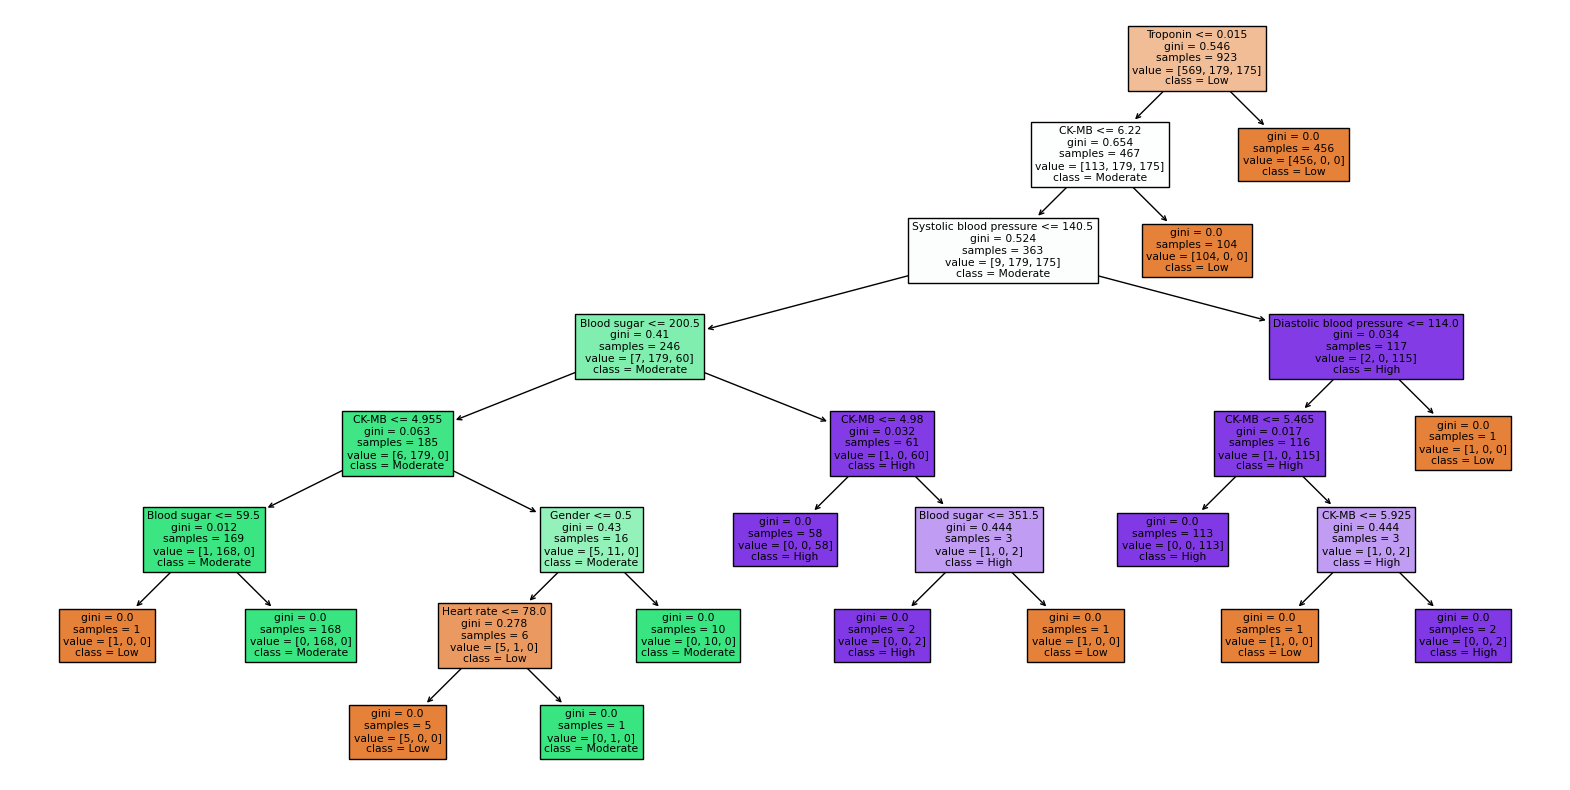

In [56]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("\nDecision Tree Results:")
print(classification_report(y_test, y_pred_dt))
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")

# Visualize the tree (for small trees)
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(dt, feature_names=X.columns, class_names=['Low','Moderate','High'], filled=True)
plt.show()

In [57]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("\nRandom Forest Results:")
print(classification_report(y_test, y_pred_rf))
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")


Random Forest Results:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       243
           1       0.97      0.99      0.98        96
           2       0.98      0.96      0.97        57

    accuracy                           0.98       396
   macro avg       0.98      0.98      0.98       396
weighted avg       0.98      0.98      0.98       396

Accuracy: 0.9823


In [58]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

print("\nGradient Boosting Results:")
print(classification_report(y_test, y_pred_gb))
print(f"Accuracy: {accuracy_score(y_test, y_pred_gb):.4f}")


Gradient Boosting Results:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       243
           1       0.98      0.99      0.98        96
           2       1.00      0.96      0.98        57

    accuracy                           0.99       396
   macro avg       0.99      0.98      0.99       396
weighted avg       0.99      0.99      0.99       396

Accuracy: 0.9874


In [59]:
from xgboost import XGBClassifier

xgb = XGBClassifier(random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("\nXGBoost Results:")
print(classification_report(y_test, y_pred_xgb))
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")


XGBoost Results:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       243
           1       0.98      0.99      0.98        96
           2       1.00      0.96      0.98        57

    accuracy                           0.99       396
   macro avg       0.99      0.98      0.99       396
weighted avg       0.99      0.99      0.99       396

Accuracy: 0.9874


c:\Users\Techno Shield\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.




Neural Network Results:
Accuracy: 0.7500


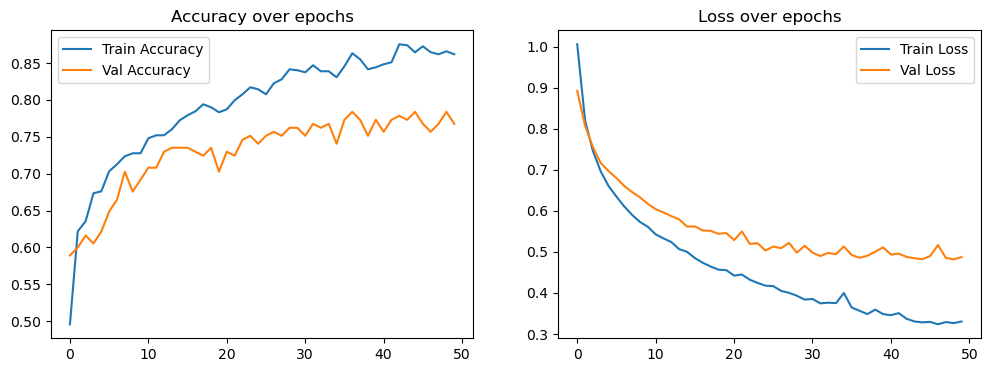

In [60]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

# Convert labels to one-hot encoding
y_train_nn = to_categorical(y_train)
y_test_nn = to_categorical(y_test)

# Build model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')  # 3 output classes
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train
history = model.fit(X_train_scaled, y_train_nn,
                    epochs=50,
                    batch_size=32,
                    validation_split=0.2,
                    verbose=0)

# Evaluate
nn_loss, nn_acc = model.evaluate(X_test_scaled, y_test_nn, verbose=0)
print("\nNeural Network Results:")
print(f"Accuracy: {nn_acc:.4f}")

# Plot training history
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy over epochs')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over epochs')
plt.legend()
plt.show()


Model Comparison:
                 Model  Accuracy
0             Baseline  0.613636
6       Neural Network  0.750000
1  Logistic Regression  0.757576
2        Decision Tree  0.972222
3        Random Forest  0.982323
4    Gradient Boosting  0.987374
5              XGBoost  0.987374


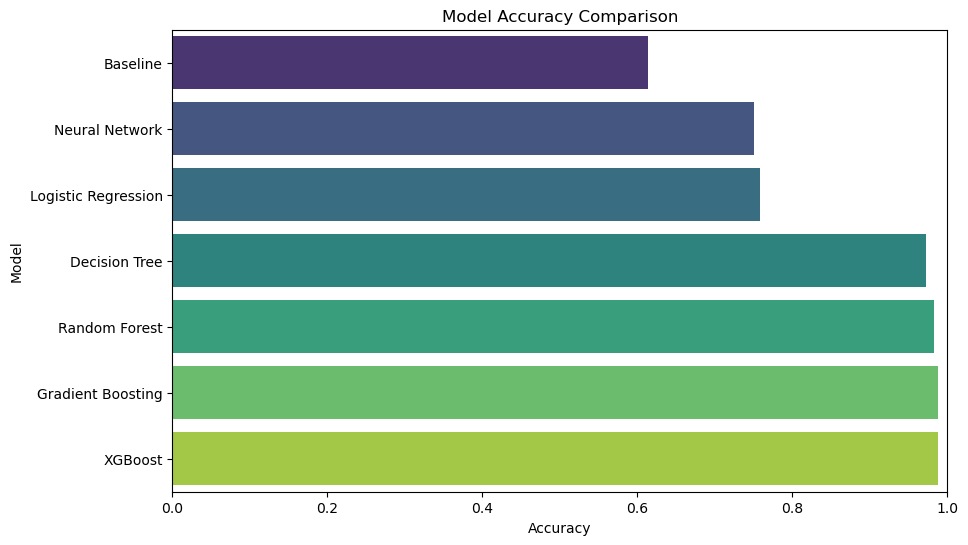

In [61]:
models = {
    'Baseline': dummy,
    'Logistic Regression': logreg,
    'Decision Tree': dt,
    'Random Forest': rf,
    'Gradient Boosting': gb,
    'XGBoost': xgb
}

results = []
for name, model in models.items():
    if name == 'Baseline':
        y_pred = model.predict(X_test)
    else:
        y_pred = model.predict(X_test_scaled if name != 'Decision Tree' and name != 'Random Forest' and name != 'Gradient Boosting' and name != 'XGBoost' else X_test)
    
    acc = accuracy_score(y_test, y_pred)
    results.append({'Model': name, 'Accuracy': acc})

# Add Neural Network
results.append({'Model': 'Neural Network', 'Accuracy': nn_acc})

results_df = pd.DataFrame(results).sort_values('Accuracy')
print("\nModel Comparison:")
print(results_df)

# Plot comparison
plt.figure(figsize=(10,6))
sns.barplot(x='Accuracy', y='Model', data=results_df, palette='viridis')
plt.title('Model Accuracy Comparison')
plt.xlim(0, 1)
plt.show()

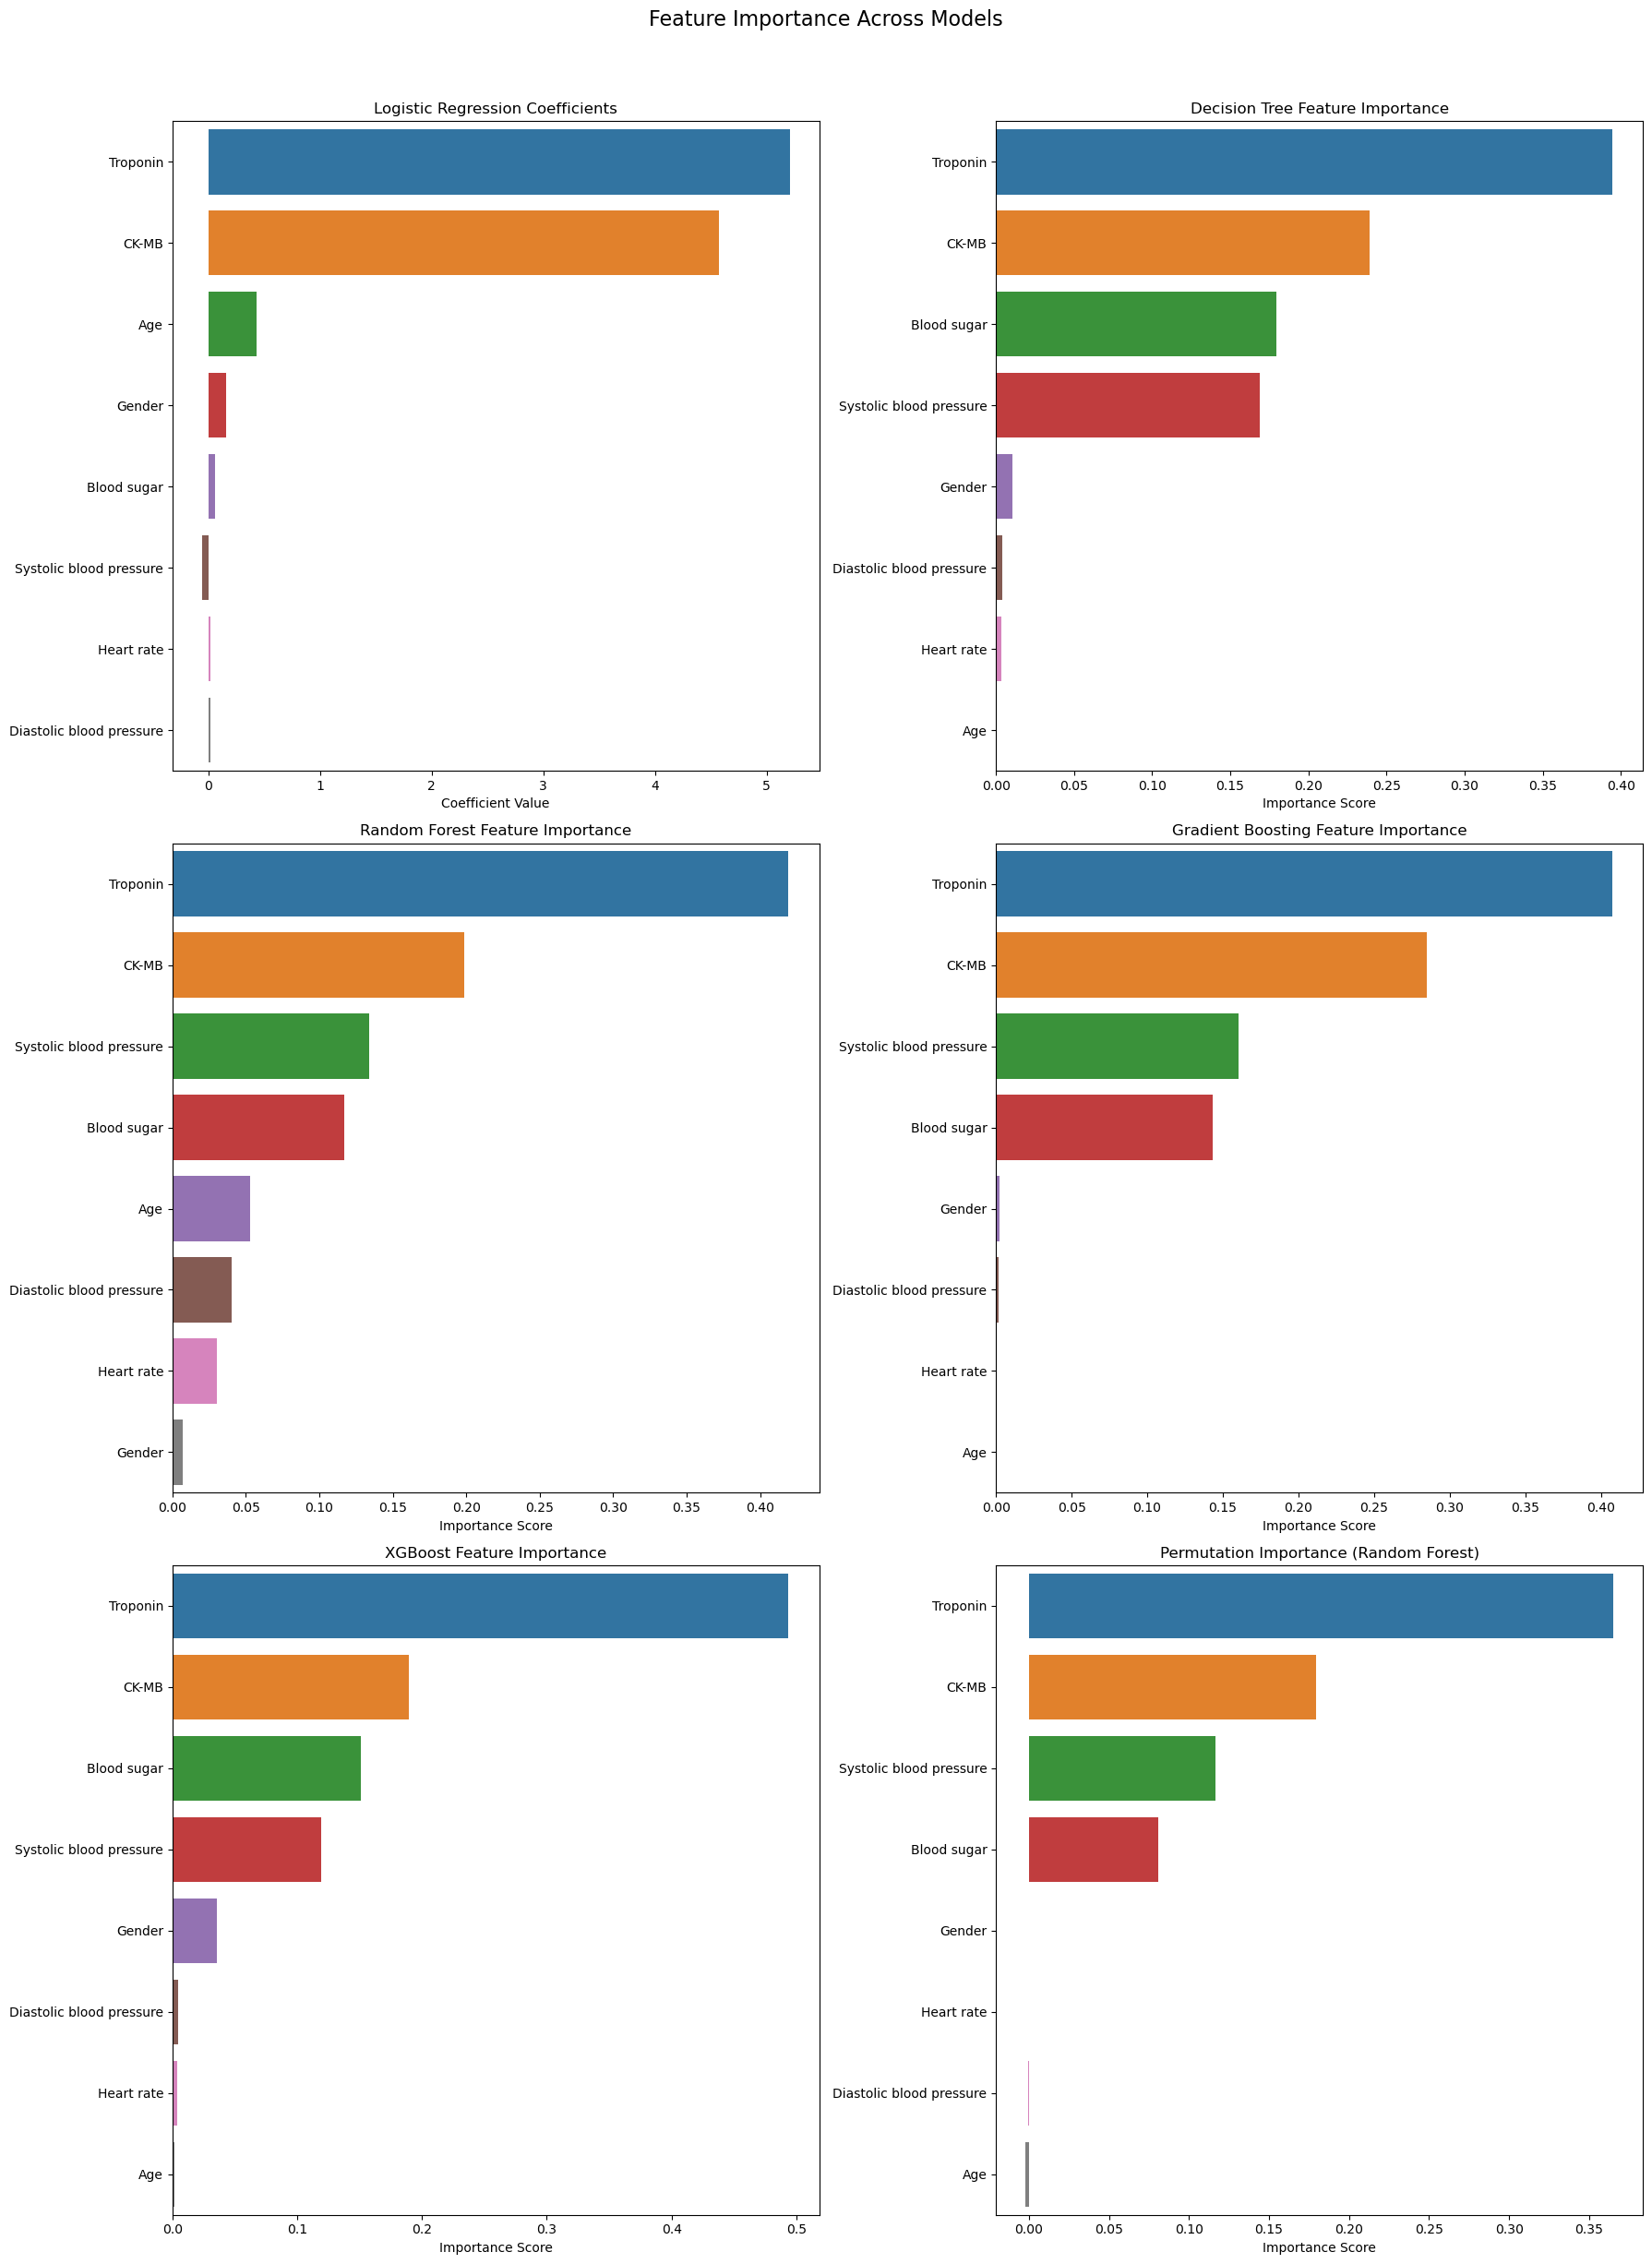

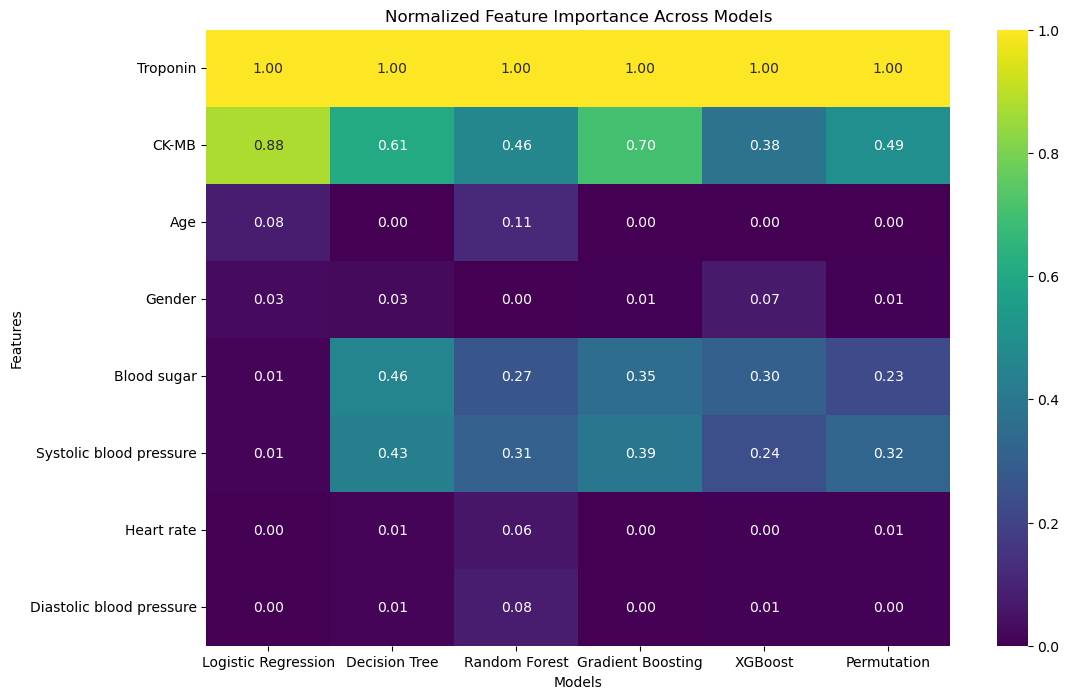

In [63]:
from sklearn.inspection import permutation_importance

# Create a figure to hold all subplots
best_rf = RandomForestClassifier(random_state=42)
best_rf.fit(X_train_scaled, y_train)
plt.figure(figsize=(18, 24))
plt.suptitle('Feature Importance Across Models', y=1.02, fontsize=16)

# Dictionary to store all models
models = {
    'Logistic Regression': logreg,
    'Decision Tree': dt,
    'Random Forest': best_rf,  # Using our tuned model
    'Gradient Boosting': gb,
    'XGBoost': xgb
}

# Plot counter
plot_num = 1

# 1. Logistic Regression Coefficients
plt.subplot(3, 2, plot_num)
plot_num += 1
if hasattr(logreg, 'coef_'):
    coefs = pd.DataFrame(logreg.coef_[0], index=X.columns, columns=['Coefficient'])
    coefs['abs'] = coefs['Coefficient'].abs()
    coefs = coefs.sort_values('abs', ascending=False)
    sns.barplot(x='Coefficient', y=coefs.index, data=coefs)
    plt.title('Logistic Regression Coefficients')
    plt.xlabel('Coefficient Value')

# 2. Decision Tree Feature Importance
plt.subplot(3, 2, plot_num)
plot_num += 1
dt_importances = pd.DataFrame(dt.feature_importances_, 
                             index=X.columns, 
                             columns=['importance']).sort_values('importance', ascending=False)
sns.barplot(x='importance', y=dt_importances.index, data=dt_importances)
plt.title('Decision Tree Feature Importance')
plt.xlabel('Importance Score')

# 3. Random Forest Feature Importance
plt.subplot(3, 2, plot_num)
plot_num += 1
rf_importances = pd.DataFrame(best_rf.feature_importances_, 
                             index=X.columns, 
                             columns=['importance']).sort_values('importance', ascending=False)
sns.barplot(x='importance', y=rf_importances.index, data=rf_importances)
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score')

# 4. Gradient Boosting Feature Importance
plt.subplot(3, 2, plot_num)
plot_num += 1
gb_importances = pd.DataFrame(gb.feature_importances_, 
                             index=X.columns, 
                             columns=['importance']).sort_values('importance', ascending=False)
sns.barplot(x='importance', y=gb_importances.index, data=gb_importances)
plt.title('Gradient Boosting Feature Importance')
plt.xlabel('Importance Score')

# 5. XGBoost Feature Importance
plt.subplot(3, 2, plot_num)
plot_num += 1
xgb_importances = pd.DataFrame(xgb.feature_importances_, 
                              index=X.columns, 
                              columns=['importance']).sort_values('importance', ascending=False)
sns.barplot(x='importance', y=xgb_importances.index, data=xgb_importances)
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance Score')

# 6. Permutation Importance (Model-agnostic)
plt.subplot(3, 2, plot_num)
result = permutation_importance(best_rf, X_test_scaled, y_test, n_repeats=10, random_state=42)
perm_importances = pd.DataFrame(result.importances_mean, 
                            index=X.columns, 
                            columns=['importance']).sort_values('importance', ascending=False)
sns.barplot(x='importance', y=perm_importances.index, data=perm_importances)
plt.title('Permutation Importance (Random Forest)')
plt.xlabel('Importance Score')

plt.tight_layout()
plt.show()

# Create a combined feature importance dataframe for comparison
importance_dfs = {
    'Logistic Regression': coefs['abs'].rename('LogReg'),
    'Decision Tree': dt_importances['importance'],
    'Random Forest': rf_importances['importance'],
    'Gradient Boosting': gb_importances['importance'],
    'XGBoost': xgb_importances['importance'],
    'Permutation': perm_importances['importance']
}

# Normalize each series to 0-1 range for comparison
combined_importance = pd.concat(importance_dfs, axis=1)
combined_importance = combined_importance.apply(lambda x: (x - x.min()) / (x.max() - x.min()))

# Plot normalized feature importance across models
plt.figure(figsize=(12, 8))
sns.heatmap(combined_importance, annot=True, cmap='viridis', fmt='.2f')
plt.title('Normalized Feature Importance Across Models')
plt.ylabel('Features')
plt.xlabel('Models')
plt.show()